# Task 1: Document Chunking & Embeddings

Corpus: Flask 3.1.0 docs (`.rst` sources from the `pallets/flask` repo).

Steps:
1. Get the raw corpus
2. **Clean the reStructuredText** (this notebook section)
3. Chunk (200 words, 20 overlap)
4. Embed with all-MiniLM-L6-v2 and verify shape (N, 384)

In [1]:
%load_ext autoreload
%autoreload 2

import json
import re
from collections import Counter
from pathlib import Path

import pandas as pd

from raghood.scrape import ROOT, RAW_DIR, scrape_all

PROCESSED_DIR = ROOT / "data" / "processed"

## 1. Get the raw corpus

The docs website is behind Cloudflare and blocks Jina Reader (it returns a bot-check page), so
`scrape_all()` downloads the same docs as `.rst` source files from the GitHub repo, pinned to tag `3.1.0`.

In [2]:
manifest = scrape_all()   # ~2 s; overwrites data/raw
df = pd.DataFrame(manifest)
print(f"{len(df)} pages, {df.words.sum():,} words")
df.sort_values("words", ascending=False).head(8)[["page", "words", "url"]]

71 pages, 59,570 words


,page,words,url
50,quickstart,4377,https://flask.palletsprojects.com/en/3.1.x/qui...
5,config,3637,https://flask.palletsprojects.com/en/3.1.x/con...
0,api,2593,https://flask.palletsprojects.com/en/3.1.x/api/
19,errorhandling,2357,https://flask.palletsprojects.com/en/3.1.x/err...
4,cli,2212,https://flask.palletsprojects.com/en/3.1.x/cli/
67,tutorial/tests,2149,https://flask.palletsprojects.com/en/3.1.x/tut...
20,extensiondev,1783,https://flask.palletsprojects.com/en/3.1.x/ext...
18,design,1774,https://flask.palletsprojects.com/en/3.1.x/des...


## 2. What does the raw text look like?

It is reStructuredText, not plain prose. Embedding models never saw `:class:` or `.. code-block::`,
so leaving the markup in adds noise to every chunk. Here is a slice of a real page:

In [3]:
raw = (RAW_DIR / "blueprints.rst").read_text(encoding="utf-8")
print(raw[:1200])

Modular Applications with Blueprints

.. currentmodule:: flask

.. versionadded:: 0.7

Flask uses a concept of *blueprints* for making application components and
supporting common patterns within an application or across applications.
Blueprints can greatly simplify how large applications work and provide a
central means for Flask extensions to register operations on applications.
A :class:`Blueprint` object works similarly to a :class:`Flask`
application object, but it is not actually an application.  Rather it is a
*blueprint* of how to construct or extend an application.

Why Blueprints?
---------------

Blueprints in Flask are intended for these cases:

* Factor an application into a set of blueprints.  This is ideal for
  larger applications; a project could instantiate an application object,
  initialize several extensions, and register a collection of blueprints.
* Register a blueprint on an application at a URL prefix and/or subdomain.
  Parameters in the URL prefix/subdomain b

Markup that appears in the corpus (counts over all 71 pages):

In [4]:
all_raw = "\n".join(p.read_text(encoding="utf-8") for p in RAW_DIR.rglob("*.rst"))
directives = Counter(re.findall(r"^\s*\.\. ([\w:-]+)::", all_raw, re.M))
roles = Counter(re.findall(r":([\w:-]+):`", all_raw))
print("directives:", dict(directives.most_common(12)))
print("roles     :", dict(roles.most_common(10)))

directives: {'code-block': 255, 'versionadded': 32, 'py:data': 29, 'autofunction': 26, 'group-tab': 24, 'autoclass': 23, 'currentmodule': 20, 'data': 18, 'sourcecode': 18, 'admonition': 13, 'versionchanged': 11, 'tabs': 8}
roles     : {'meth': 135, 'doc': 130, 'class': 103, 'data': 101, 'func': 82, 'attr': 66, 'file': 50, 'ref': 23, 'exc': 22, 'mod': 8}


## 3. Cleaning rules

| Markup | What we do | Why |
|---|---|---|
| `Title` + `=====` underline | `# Title` (level by order of first appearance) | Keeps section structure for citations and eval labels |
| `.. code-block::`, `.. sourcecode::`, `text::` literal blocks | Fenced ` ``` ` block, contents untouched | Flask questions often hinge on code |
| `:class:`~flask.Flask``, `:meth:`...`, `:doc:`text <page>`` | Just the readable name (`Flask`) | Roles are Sphinx syntax; the name is the useful part |
| ` ``code`` `, `` `Click`_ `` links | `` `code` ``, `Click` | Plain text |
| `.. note::`, `.. warning::`, `.. admonition::` | `Note: ...` etc., body kept | Real content |
| `.. versionadded:: 0.7` | `Added in version 0.7.` | Real content |
| `.. py:data:: DEBUG` (+ body) | Name line + description | Config docs live here |
| `.. tabs::` / `.. tab::` | Drop marker, keep content | Layout only |
| `.. autofunction::`, `.. autoclass::` | **Drop** | Docstrings are not in the `.rst`, so these are bare names with no content that would only match keyword searches |
| `.. toctree::`, `.. currentmodule::`, `.. image::`, link targets, `----` | Drop | Navigation / layout only |

The implementation lives in [`src/raghood/clean.py`](../src/raghood/clean.py) (with helpers `_role`,
`_inline` and `_block`) so the Task 4 chunk-size sweep re-runs exactly this code. Its body is printed below;
`tests/test_clean.py` has one test per rule in the table.

In [5]:
import inspect

from raghood.clean import clean_rst

print(inspect.getsource(clean_rst))

def clean_rst(text: str) -> str:
    """Strip Sphinx/RST markup, keeping headings, code blocks and prose."""
    lines = text.splitlines()
    out: list[str] = []
    level_of: dict[str, int] = {}  # underline char -> heading level, in order of first appearance
    i = 0
    while i < len(lines):
        line = lines[i]

        # headings: a text line followed by an underline at least as long
        if (i + 1 < len(lines) and line.strip() and not line.startswith(" ")
                and UNDERLINE.match(lines[i + 1]) and len(lines[i + 1].strip()) >= len(line.strip())):
            ch = lines[i + 1].strip()[0]
            level = level_of.setdefault(ch, len(level_of) + 1)
            out += ["", "#" * min(level, 4) + " " + line.strip(), ""]
            i += 2
            continue

        # transitions ("----" with no heading text above it)
        if UNDERLINE.match(line):
            i += 1
            continue

        # link targets (".. _x:"), substitutions, comments: drop with th

## 4. Before / after

In [6]:
def show(page, start_marker, n=900):
    """Print a slice of a raw page and the same slice after clean_rst()."""
    raw = (RAW_DIR / f"{page}.rst").read_text(encoding="utf-8")
    i = raw.index(start_marker)
    piece = raw[i:i + n]
    print("=" * 20, "RAW", page); print(piece)
    print("=" * 20, "CLEAN"); print(clean_rst(piece))

show("blueprints", "A :class:`Blueprint` object", 700)

==================== RAW blueprints
A :class:`Blueprint` object works similarly to a :class:`Flask`
application object, but it is not actually an application.  Rather it is a
*blueprint* of how to construct or extend an application.

Why Blueprints?
---------------

Blueprints in Flask are intended for these cases:

* Factor an application into a set of blueprints.  This is ideal for
  larger applications; a project could instantiate an application object,
  initialize several extensions, and register a collection of blueprints.
* Register a blueprint on an application at a URL prefix and/or subdomain.
  Parameters in the URL prefix/subdomain become common view arguments
  (with defaults) across all view functions in the bluep
==================== CLEAN
A Blueprint object works similarly to a Flask
application object, but it is not actually an application.  Rather it is a
*blueprint* of how to construct or extend an application.

# Why Blueprints?

Blueprints in Flask are intended for 

In [7]:
show("config", ".. py:data:: DEBUG", 900)

==================== RAW config
.. py:data:: DEBUG

    Whether debug mode is enabled. When using ``flask run`` to start the development
    server, an interactive debugger will be shown for unhandled exceptions, and the
    server will be reloaded when code changes. The :attr:`~flask.Flask.debug` attribute
    maps to this config key. This is set with the ``FLASK_DEBUG`` environment variable.
    It may not behave as expected if set in code.

    **Do not enable debug mode when deploying in production.**

    Default: ``False``

.. py:data:: TESTING

    Enable testing mode. Exceptions are propagated rather than handled by the
    the app's error handlers. Extensions may also change their behavior to
    facilitate easier testing. You should enable this in your own tests.

    Default: ``False``

.. py:data:: PROPAGATE_EXCEPTIONS

    Exceptions are re-raised rather than being handled by the app's error
    handlers. 
==================== CLEAN
DEBUG
Whether debug mode is enabled. Whe

In [8]:
show("quickstart", ".. code-block:: python", 350)

==================== RAW quickstart
.. code-block:: python

    from flask import Flask

    app = Flask(__name__)

    @app.route("/")
    def hello_world():
        return "<p>Hello, World!</p>"

So what did that code do?

1.  First we imported the :class:`~flask.Flask` class. An instance of
    this class will be our WSGI application.
2.  Next we create an instance of this class. 
==================== CLEAN
```python
from flask import Flask

app = Flask(__name__)

@app.route("/")
def hello_world():
    return "<p>Hello, World!</p>"
```

So what did that code do?

1.  First we imported the Flask class. An instance of
    this class will be our WSGI application.
2.  Next we create an instance of this class.



## 5. Sanity checks

After cleaning, scan every page for markup that survived (outside code fences, where raw syntax is legitimate).

In [9]:
CHECKS = {
    "directive (.. x::)": r"^\s*\.\. [\w:-]+::",
    "role (:x:`...`)":    r":[\w:-]+:`",
    "double backticks":   r"(?<!`)``(?!`)",
    "underline rows":     r"^[=\-~^]{4,}$",
    "trailing '::'":      r"::\s*$",
}
cleaned = {}
rows = []
for m in manifest:
    text = clean_rst((ROOT / m["path"]).read_text(encoding="utf-8"))
    cleaned[m["page"]] = text
    outside = re.sub(r"```.*?```", "", text, flags=re.S)  # ignore code fences
    rows.append({"page": m["page"], "raw_words": m["words"], "clean_words": len(text.split()),
                 **{k: len(re.findall(p, outside, re.M)) for k, p in CHECKS.items()}})
check = pd.DataFrame(rows)
print("leftover markup per check (want all 0):")
print(check[list(CHECKS)].sum().to_string())
print(f"\nwords: {check.raw_words.sum():,} -> {check.clean_words.sum():,}")

leftover markup per check (want all 0):
directive (.. x::)    0
role (:x:`...`)       0
double backticks      0
underline rows        0
trailing '::'         0

words: 59,570 -> 58,425


In [10]:
# pages that lost the most text (the API page loses its autodoc name lists)
check.assign(lost=check.raw_words - check.clean_words).sort_values("lost", ascending=False).head(6)[["page", "raw_words", "clean_words", "lost"]]

,page,raw_words,clean_words,lost
0,api,2593,2339,254
4,cli,2212,2139,73
67,tutorial/tests,2149,2087,62
22,index,257,199,58
61,tutorial/index,306,250,56
35,patterns/javascript,1198,1151,47


In [11]:
# every code fence must be opened and closed
unbalanced = [p for p, t in cleaned.items() if t.count("```") % 2]
print("pages with unbalanced code fences:", unbalanced)

pages with unbalanced code fences: []


## 6. Save cleaned pages

`data/processed/<page>.md` plus `manifest.jsonl` (same fields as the raw manifest, with the cleaned word count).
Next step: chunk these files.

In [12]:
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
out_manifest = []
for m in manifest:
    dest = PROCESSED_DIR / f"{m['page']}.md"
    dest.parent.mkdir(parents=True, exist_ok=True)
    dest.write_text(cleaned[m["page"]], encoding="utf-8")
    out_manifest.append({**m, "path": dest.relative_to(ROOT).as_posix(), "words": len(cleaned[m["page"]].split())})

with open(PROCESSED_DIR / "manifest.jsonl", "w", encoding="utf-8") as f:
    for m in out_manifest:
        f.write(json.dumps(m) + "\n")
print(f"saved {len(out_manifest)} pages, {sum(m['words'] for m in out_manifest):,} words -> {PROCESSED_DIR}")

saved 71 pages, 58,425 words -> D:\Coding Stuff\rag-under-hood\data\processed

## 7. Chunking

Fixed-size sliding window: **200 words per chunk, 20 words shared between neighbours** (step = 180).

Design choices:
- **Words are counted, but the original text is sliced.** `re.finditer(r"\S+")` gives each word's character span, so a chunk keeps its newlines and code indentation (`text.split()` + `" ".join()` would flatten them).
- **One page at a time**, so every chunk has exactly one source URL.
- **No tiny tail chunk.** If the last window would add fewer than `overlap` new words, the previous chunk is stretched to cover them instead (so a chunk can hold up to `size + overlap - 1` = 219 words).
- **Section label** = nearest `#` heading above the chunk's first word. Headings inside code fences are ignored (a Python `# comment` is not a heading).
- Purely fixed-size, so a chunk can cut a code block in half. We measure how often below; Task 4 compares other strategies.

`size` and `overlap` are parameters, which is what makes the Task 4 sweep possible. The implementation is in
[`src/raghood/chunk.py`](../src/raghood/chunk.py); `tests/test_chunk.py` pins the invariants checked below.

In [13]:
from raghood.chunk import chunk_page, heading_positions

print(inspect.getsource(chunk_page))

def chunk_page(text: str, size: int = 200, overlap: int = 20) -> list[dict]:
    """Split one page into windows of `size` words sharing `overlap` words with the next.

    If the final window would add fewer than `overlap` new words, it is folded into the
    previous chunk instead, so a page never ends in a tiny near-duplicate chunk (a chunk
    can therefore hold up to `size + overlap - 1` words).

    Returns dicts with the word range, character range, section title, n_words and text.
    """
    if overlap >= size:
        raise ValueError(f"overlap ({overlap}) must be smaller than size ({size})")

    words = list(WORD.finditer(text))
    n, step = len(words), size - overlap
    if n == 0:
        return []

    spans, start = [], 0
    while True:
        end = min(start + size, n)
        spans.append([start, end])
        if end == n:
            break
        start += step

    if len(spans) > 1 and spans[-1][1] - spans[-2][1] < overlap:
        spans[-2][1] = spans[-1][1]
   

Try it on one small page first: two chunks, and the seam between them should repeat the same 20 words.

In [14]:
demo_text = (ROOT / "data" / "processed" / "patterns" / "favicon.md").read_text(encoding="utf-8")
demo = chunk_page(demo_text)
print("words on page:", len(demo_text.split()), "| chunks:", [c["n_words"] for c in demo])
print("\nEND of chunk 0  :", " ".join(demo[0]["text"].split()[-20:]))
print("\nSTART of chunk 1:", " ".join(demo[1]["text"].split()[:20]))

words on page:

 308 | chunks: [200, 128]

END of chunk 0  : you can't do that you're out of luck. If however your application is the root you can simply route a

START of chunk 1: you can't do that you're out of luck. If however your application is the root you can simply route a


### Chunk the whole corpus

In [15]:
from raghood.chunk import chunk_corpus

SIZE, OVERLAP = 200, 20
chunks = chunk_corpus(out_manifest, ROOT, size=SIZE, overlap=OVERLAP)

cdf = pd.DataFrame(chunks)
print(f"{len(cdf)} chunks from {cdf.page.nunique()} pages")
cdf.n_words.describe().round(1).to_frame("words per chunk").T

344 chunks from 71 pages


,count,mean,std,min,25%,50%,75%,max
words per chunk,344.0,185.7,36.5,43.0,200.0,200.0,200.0,218.0


### Checks

These are asserts, so a bug in the window logic fails loudly instead of silently producing bad chunks.

In [16]:
step = SIZE - OVERLAP
for page, g in cdf.groupby("page", sort=False):
    g = g.sort_values("chunk_no")
    n_page_words = len((ROOT / "data" / "processed" / f"{page}.md").read_text(encoding="utf-8").split())

    # 1. coverage: no word of the page is dropped
    assert g.start_word.iloc[0] == 0 and g.end_word.iloc[-1] == n_page_words, page

    # 2. overlap: neighbours share exactly OVERLAP words (by index and by content)
    for a, b in zip(g.itertuples(), g.iloc[1:].itertuples()):
        assert b.start_word == a.end_word - OVERLAP, (page, a.chunk_no)
        assert a.text.split()[-OVERLAP:] == b.text.split()[:OVERLAP], (page, a.chunk_no)

    # 3. sizes: ordinary chunks are SIZE..SIZE+OVERLAP-1 words; the last one is never a tiny leftover
    assert (g.n_words.iloc[:-1] >= SIZE).all() and (g.n_words <= SIZE + OVERLAP - 1).all(), page
    if len(g) > 1:
        assert g.n_words.iloc[-1] >= 2 * OVERLAP, page

# 4. every chunk's text really is a slice of its page
assert all(len(c["text"].split()) == c["n_words"] for c in chunks)
print("all checks passed")

cut = cdf[cdf.text.str.count("```") % 2 == 1]
print(f"\nchunks that cut a code block in half: {len(cut)} / {len(cdf)} ({len(cut) / len(cdf):.0%})")
print(f"chunks with no section label: {cdf.section.isna().sum()}")

all checks passed

chunks that cut a code block in half: 85 / 344 (25%)
chunks with no section label: 0


### Chunk statistics

chunks per page: median 3, max 24 (quickstart)
pages with a single chunk: 9 / 71


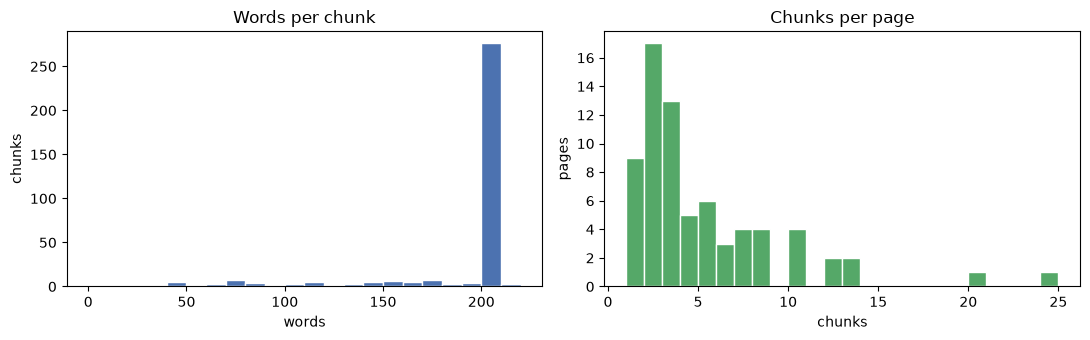

In [17]:
import matplotlib.pyplot as plt

per_page = cdf.groupby("page").size().sort_values(ascending=False)
print(f"chunks per page: median {per_page.median():.0f}, max {per_page.max()} ({per_page.index[0]})")
print(f"pages with a single chunk: {(per_page == 1).sum()} / {len(per_page)}")

fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
ax[0].hist(cdf.n_words, bins=range(0, SIZE + OVERLAP + 10, 10), color="#4C72B0", edgecolor="white")
ax[0].set(title="Words per chunk", xlabel="words", ylabel="chunks")
ax[1].hist(per_page, bins=range(1, per_page.max() + 2), color="#55A868", edgecolor="white")
ax[1].set(title="Chunks per page", xlabel="chunks", ylabel="pages")
plt.tight_layout()

fig_dir = ROOT / "reports" / "figures"
fig_dir.mkdir(parents=True, exist_ok=True)
fig.savefig(fig_dir / "chunk_stats.png", dpi=150)
plt.show()

### Sample chunks

In [18]:
for i in (0, cdf[cdf.page == "quickstart"].id.iloc[3], cdf[cdf.page == "config"].id.iloc[10]):
    c = cdf.loc[i]
    print("=" * 70)
    print(f"id={c.id}  page={c.page}  chunk {c.chunk_no}  words={c.n_words}\nsection: {c.section}\n{c.url}")
    print("-" * 70)
    print(c.text[:700] + (" ..." if len(c.text) > 700 else ""))

id=0  page=api  chunk 0  words=200
section: API
https://flask.palletsprojects.com/en/3.1.x/api/
----------------------------------------------------------------------
# API

This part of the documentation covers all the interfaces of Flask. For
parts where Flask depends on external libraries, we document the most
important right here and provide links to the canonical documentation.

## Application Object

## Blueprint Objects

## Incoming Request Data

request
To access incoming request data, you can use the global `request`
object. Flask parses incoming request data for you and gives you
access to it through that global object. Internally Flask makes
sure that you always get the correct data for the active thread if you
are in a multithreaded environment.

This is a proxy. See notes-on-proxies for more information.

The request object is an instance of  ...
id=216  page=quickstart  chunk 3  words=200
section: Debug Mode
https://flask.palletsprojects.com/en/3.1.x/quickstart/
---------

### Save

`data/processed/chunks.jsonl`: one line per chunk. The `id` is the row number in the embedding matrix we build next,
so `embeddings[id]` is always the vector for `chunks[id]`.

In [19]:
with open(PROCESSED_DIR / "chunks.jsonl", "w", encoding="utf-8") as f:
    for c in chunks:
        f.write(json.dumps(c, ensure_ascii=False) + "\n")
assert [c["id"] for c in chunks] == list(range(len(chunks)))
print(f"saved {len(chunks)} chunks -> {PROCESSED_DIR / 'chunks.jsonl'}")

saved 344 chunks -> D:\Coding Stuff\rag-under-hood\data\processed\chunks.jsonl


## 8. Embeddings

Encode every chunk with `sentence-transformers/all-MiniLM-L6-v2` into a single `(N, 384)` float32 matrix,
saved as `data/processed/embeddings.npy`.

Row `i` of that matrix is the vector for the chunk with `id == i` — that is why the chunk ids were assigned
as row numbers. All later steps (manual cosine search, FAISS, ChromaDB) rely on this alignment.

In [20]:
import numpy as np
import torch

from raghood.embed import MODEL_NAME, embed_chunks, load_model, token_stats

model = load_model()          # ~90 MB, downloaded once into ~/.cache/huggingface
print(f"{MODEL_NAME} on {model.device}")
print(f"({torch.cuda.get_device_name(0)})" if model.device.type == "cuda" else "(no GPU)")
print(model)

D:\Coding Stuff\rag-under-hood\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 7186.21it/s]

sentence-transformers/all-MiniLM-L6-v2 on cuda:0
(NVIDIA GeForce RTX 3050 Laptop GPU)
SentenceTransformer(
  (0): Transformer({'transformer_task': 'feature-extraction', 'modality_config': {'text': {'method': 'forward', 'method_output_name': 'last_hidden_state'}}, 'module_output_name': 'token_embeddings', 'architecture': 'BertModel'})
  (1): Pooling({'embedding_dimension': 384, 'pooling_mode': 'mean', 'include_prompt': True})
  (2): Normalize({'module_input_name': 'sentence_embedding', 'module_output_name': 'sentence_embedding'})
)


### What the model is doing

The `SentenceTransformer` printed above is a **3-module** pipeline, which is exactly the architecture the
Task 3 report has to explain:

1. **Transformer** — a 6-layer BERT-style encoder (MiniLM). It turns `T` input tokens into `T` contextual
   vectors of 384 dimensions each.
2. **Pooling** — mean pooling over those `T` token vectors (padding tokens excluded via the attention mask),
   collapsing a variable-length sequence into **one fixed 384-d sentence vector**.
3. **Normalize** — divides each vector by its own L2 norm, so every output vector has length exactly 1.

That third module matters for Task 2. Because `|d| = 1` for every chunk and `|q| = 1` for the query,

$$\text{cosine}(q, d) = \frac{q \cdot d}{|q|\,|d|} = q \cdot d$$

so the whole search collapses into **one matrix multiplication**. We still write the division out by hand in
Task 2 (that is the exercise, and it keeps the function correct for un-normalised input), but this is why
pre-normalising a corpus is the standard trick — and why FAISS's `IndexFlatIP` (inner product) is the right
index to compare against later.

`max_seq_length` is the hard cap on tokens: anything past it is truncated and simply cannot influence the vector.

In [21]:
transformer, pooling = model[0], model[1]
print(f"max_seq_length      : {model.max_seq_length} tokens")
print(f"embedding dimension : {model.get_embedding_dimension()}")
print(f"encoder layers      : {transformer.auto_model.config.num_hidden_layers}")
print(f"attention heads     : {transformer.auto_model.config.num_attention_heads}")
print(f"parameters          : {sum(p.numel() for p in model.parameters()):,}")
print(f"pooling mode        : {pooling.pooling_mode}")
print(f"tokenizer           : {type(transformer.tokenizer).__name__}")

max_seq_length      : 256 tokens
embedding dimension : 384
encoder layers      : 6
attention heads     : 12
parameters          : 22,713,216
pooling mode        : mean
tokenizer           : BertTokenizer


### Do our 200-word chunks fit in 256 tokens?

WordPiece splits rare words and identifiers into several tokens (`teardown_appcontext` becomes many pieces),
so 200 words of technical prose is usually **more** than 200 tokens. Anything beyond `max_seq_length` is
silently dropped from the vector, so it is worth measuring rather than assuming.

In [22]:
stats = token_stats([c["text"] for c in chunks], model)
tok_lens = stats["lengths"]                      # includes [CLS] / [SEP]
over = tok_lens > model.max_seq_length

tokens_per_word = tok_lens.mean() / cdf.n_words.mean()
print(f"tokens per chunk: min {tok_lens.min()}, median {np.median(tok_lens):.0f}, max {tok_lens.max()}")
print(f"tokens per word : {tokens_per_word:.2f} average")
print(f"chunks truncated at {model.max_seq_length} tokens: {over.sum()} / {len(chunks)} ({over.mean():.0%})")

lost = tok_lens[over] - model.max_seq_length
print(f"  tokens lost in those chunks: median {np.median(lost):.0f}, max {lost.max()}")
print(f"  words that actually fit in {model.max_seq_length} tokens: ~{model.max_seq_length / tokens_per_word:.0f}")

worst_idx = np.argsort(-tok_lens)[:3]
print("\nlongest chunks:")
print(cdf.loc[worst_idx, ["id", "page", "section", "n_words"]].assign(tokens=tok_lens[worst_idx]).to_string(index=False))

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (285 > 256). Running this sequence through the model will result in indexing errors


tokens per chunk: min 64, median 324, max 745
tokens per word : 1.79 average
chunks truncated at 256 tokens: 297 / 344 (86%)
  tokens lost in those chunks: median 87, max 489
  words that actually fit in 256 tokens: ~143

longest chunks:
 id           page                     section  n_words  tokens
332          views Method Dispatching and APIs      200     745
308 tutorial/tests               Test Coverage      200     607
316 tutorial/tests                        Blog      200     597


**This is a significant finding, not a detail.** At 1.8 WordPiece tokens per word (identifiers like
`teardown_appcontext` and punctuation-heavy code inflate the count), a 200-word chunk is a ~324-token chunk,
but MiniLM stops reading at 256. So **86% of our chunks have their tail silently ignored** by the embedding
model — the text is still returned to the LLM when retrieved, but it contributed nothing to the vector that
decided whether the chunk was retrieved in the first place.

Consequences we carry forward:

- **Task 1 stays at 200 words** — that is the size the brief specifies, and this notebook's job is to
  document the pipeline honestly, not to tune it.
- **Task 4 gets a concrete hypothesis to test:** larger chunks cannot buy more *signal*, only more hidden
  text. Re-running `chunk_corpus` at other sizes and re-counting tokens gives the picture below.
- **Beware the mean.** `256 / 1.79 ≈ 143 words` suggests a ~140-word chunk would fit, but that reasoning
  uses the *average* tokens-per-word and the distribution has a long right tail (code-dense chunks run far
  above 1.79). Measured, a 140-word chunk still truncates 35% of the time. Only ~100 words gets close to
  fitting, and even then not entirely.

In [23]:
# how much of each chunk the encoder can actually see, by chunk size
rows = []
for size in (100, 140, 200, 300, 500):
    cs = chunk_corpus(out_manifest, ROOT, size=size, overlap=OVERLAP)
    st = token_stats([c["text"] for c in cs], model)
    rows.append({"words": size, "chunks": len(cs), "median tokens": st["median"],
                 "max tokens": st["max"], "truncated": f"{st['frac_truncated']:.0%}"})
pd.DataFrame(rows).set_index("words")

,chunks,median tokens,max tokens,truncated
words,,,,
100,728,166.0,495,8%
140,503,227.0,640,35%
200,344,323.5,745,86%
300,233,485.0,983,89%
500,153,772.0,1449,90%


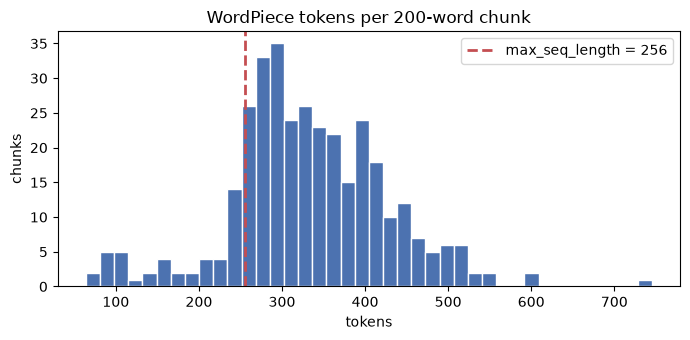

In [24]:
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.hist(tok_lens, bins=40, color="#4C72B0", edgecolor="white")
ax.axvline(model.max_seq_length, color="#C44E52", ls="--", lw=2,
           label=f"max_seq_length = {model.max_seq_length}")
ax.set(title="WordPiece tokens per 200-word chunk", xlabel="tokens", ylabel="chunks")
ax.legend()
plt.tight_layout()
fig.savefig(fig_dir / "token_lengths.png", dpi=150)
plt.show()

### Encode

`encode()` tokenizes, runs the encoder, mean-pools and returns one row per chunk.

In [25]:
%%time
embeddings = embed_chunks(chunks, model=model, batch_size=32, show_progress_bar=True)

Batches:   0%|          | 0/11 [00:00<?, ?it/s]

Batches:   9%|▉         | 1/11 [00:00<00:02,  4.47it/s]

Batches:  27%|██▋       | 3/11 [00:00<00:00,  8.20it/s]

Batches:  45%|████▌     | 5/11 [00:00<00:00,  9.93it/s]

Batches:  64%|██████▎   | 7/11 [00:00<00:00,  9.93it/s]

Batches:  82%|████████▏ | 9/11 [00:00<00:00, 10.49it/s]

Batches: 100%|██████████| 11/11 [00:01<00:00, 11.33it/s]

Batches: 100%|██████████| 11/11 [00:01<00:00, 10.17it/s]

CPU times: total: 1.36 s
Wall time: 1.08 s


In [26]:
print(f"shape : {embeddings.shape}      (chunks, embedding dim)")
print(f"dtype : {embeddings.dtype}")
print(f"memory: {embeddings.nbytes / 1024:.0f} KB")

assert embeddings.shape == (len(chunks), 384), embeddings.shape
assert embeddings.dtype == np.float32
assert np.isfinite(embeddings).all(), "NaN/inf in embeddings"
print("\nshape verified: (N, 384)")

shape : (344, 384)      (chunks, embedding dim)
dtype : float32
memory: 516 KB

shape verified: (N, 384)


### Checks

1. **Row alignment** — re-encoding a few chunks on their own must reproduce the same rows, i.e. `embeddings[i]`
   really belongs to `chunks[i]`.
2. **Norms** — confirm the `Normalize` module really did its job, i.e. every row has length exactly 1.
3. **Sanity of the space** — two chunks from the same page should, on average, be more similar than two
   chunks from unrelated pages.

In [27]:
probe = [0, len(chunks) // 2, len(chunks) - 1]
again = model.encode([chunks[i]["text"] for i in probe], convert_to_numpy=True)
assert np.allclose(again, embeddings[probe], atol=1e-5), "row order does not match chunk ids"
print("row alignment: embeddings[i] matches chunks[i]")

norms = np.linalg.norm(embeddings, axis=1)
print(f"\nL2 norms: min {norms.min():.6f}, max {norms.max():.6f}")
assert np.allclose(norms, 1.0, atol=1e-5), "Normalize module did not produce unit vectors"
print("all rows are unit length -> cosine similarity reduces to a plain dot product")

row alignment: embeddings[i] matches chunks[i]



L2 norms: min 1.000000, max 1.000000
all rows are unit length -> cosine similarity reduces to a plain dot product


In [28]:
# same-page pairs vs cross-page pairs (a preview of Task 2's cosine: rows are already unit length)
sim = embeddings @ embeddings.T
np.fill_diagonal(sim, np.nan)

pages = cdf.page.to_numpy(dtype=object)          # plain ndarray: pandas string dtype will not broadcast to 2-D
same_page = pages[:, None] == pages[None, :]
print(f"mean cosine, chunks from the same page : {np.nanmean(sim[same_page]):.3f}")
print(f"mean cosine, chunks from different pages: {np.nanmean(sim[~same_page]):.3f}")

i, j = np.unravel_index(np.nanargmax(sim), sim.shape)
print(f"\nmost similar pair ({sim[i, j]:.3f}): "
      f"[{i}] {cdf.page[i]} / {cdf.section[i]}   <->   [{j}] {cdf.page[j]} / {cdf.section[j]}")

mean cosine, chunks from the same page : 0.524
mean cosine, chunks from different pages: 0.345

most similar pair (0.899): [69] deploying/eventlet / eventlet   <->   [71] deploying/gevent / gevent


### Save

`embeddings.npy` alongside `chunks.jsonl`. Both are gitignored — `scrape.py` plus this notebook regenerate them.

In [29]:
emb_path = PROCESSED_DIR / "embeddings.npy"
np.save(emb_path, embeddings)

reloaded = np.load(emb_path)
assert reloaded.shape == embeddings.shape and np.array_equal(reloaded, embeddings)
print(f"saved {reloaded.shape} -> {emb_path}  ({emb_path.stat().st_size / 1024:.0f} KB)")
print(f"\nTask 1 complete: {len(chunks)} chunks x 384 dimensions, aligned with chunks.jsonl")

saved (344, 384) -> D:\Coding Stuff\rag-under-hood\data\processed\embeddings.npy  (516 KB)

Task 1 complete: 344 chunks x 384 dimensions, aligned with chunks.jsonl
